In [1]:
import pandas as pd 


In [3]:
data = pd.read_excel("data_original.xlsx")

In [4]:
data

,ID,Name of the food,Image Before Eaten,Weight Before Eaten (g),Image After Eaten,Weight After Eaten (g),Visual Estimation by Observer (1-7)
0,1,Bubur,000_000_DSC_0016_bef.JPG,343,000_000_DSC_0032_aft.JPG,330,1
1,2,Nasi,001_001_DSC_0059_bef.JPG,130,001_001_DSC_0108_aft.JPG,122,3
2,3,Nasi,001_002_DSC_0066_bef.JPG,135,001_002_DSC_0095_aft.JPG,127,1
3,4,Nasi,001_003_DSC_0067_bef.JPG,146,001_003_DSC_0097_aft.JPG,1,7
4,5,Nasi,001_008_DSC_0055_bef.JPG,139,001_008_DSC_0101_aft.JPG,25,6
...,...,...,...,...,...,...,...
673,695,sayur buncis soun,048_693_DSC_0525_bef.JPG,20,048_693_DSC_0573_aft.JPG,20,1
674,696,sayur buncis soun,048_694_DSC_0526_bef.JPG,20,048_694_DSC_0572_aft.JPG,19,1
675,697,sayur buncis soun,048_695_DSC_0527_bef.JPG,21,048_695_DSC_0603_aft.JPG,20,4
676,698,Sayur buncis soun kacang merah,049_686_DSC_0546_bef.JPG,50,049_686_DSC_0594_aft.JPG,22,4


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678 entries, 0 to 677
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   ID                                   678 non-null    int64 
 1   Name of the food                     678 non-null    object
 2   Image Before Eaten                   678 non-null    object
 3   Weight Before Eaten (g)              678 non-null    int64 
 4   Image After Eaten                    678 non-null    object
 5   Weight After Eaten (g)               678 non-null    int64 
 6   Visual Estimation by Observer (1-7)  678 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 37.2+ KB


In [6]:
data2 = pd.read_excel("data_original_edit.xlsx")

In [7]:
data2

,ID,Name of the food,Image Before Eaten,Weight Before Eaten (g),Image After Eaten,Weight After Eaten (g),Visual Estimation by Observer (1-7)
0,1,Bubur,000_000_DSC_0016_bef.JPG,343,000_000_DSC_0032_aft.JPG,330,1
1,2,Nasi,001_001_DSC_0059_bef.JPG,130,001_001_DSC_0108_aft.JPG,122,3
2,3,Nasi,001_002_DSC_0066_bef.JPG,135,001_002_DSC_0095_aft.JPG,127,1
3,4,Nasi,001_003_DSC_0067_bef.JPG,146,001_003_DSC_0097_aft.JPG,1,7
4,5,Nasi,001_008_DSC_0055_bef.JPG,139,001_008_DSC_0101_aft.JPG,25,6
...,...,...,...,...,...,...,...
519,536,Oseng Tahu,033_472_DSC_0967_bef.JPG,32,033_472_DSC_0011_aft.JPG,23,2
520,537,Oseng Tahu,033_473_DSC_0929_bef.JPG,34,033_473_DSC_0007_aft.JPG,0,7
521,538,Oseng Tahu,033_474_DSC_0933_bef.JPG,44,033_474_DSC_0998_aft.JPG,42,1
522,539,Oseng Tahu,033_475_DSC_0941_bef.JPG,43,033_475_DSC_1007_aft.JPG,23,4


In [9]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   ID                                   524 non-null    int64 
 1   Name of the food                     524 non-null    object
 2   Image Before Eaten                   524 non-null    object
 3   Weight Before Eaten (g)              524 non-null    int64 
 4   Image After Eaten                    524 non-null    object
 5   Weight After Eaten (g)               524 non-null    int64 
 6   Visual Estimation by Observer (1-7)  524 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 28.8+ KB


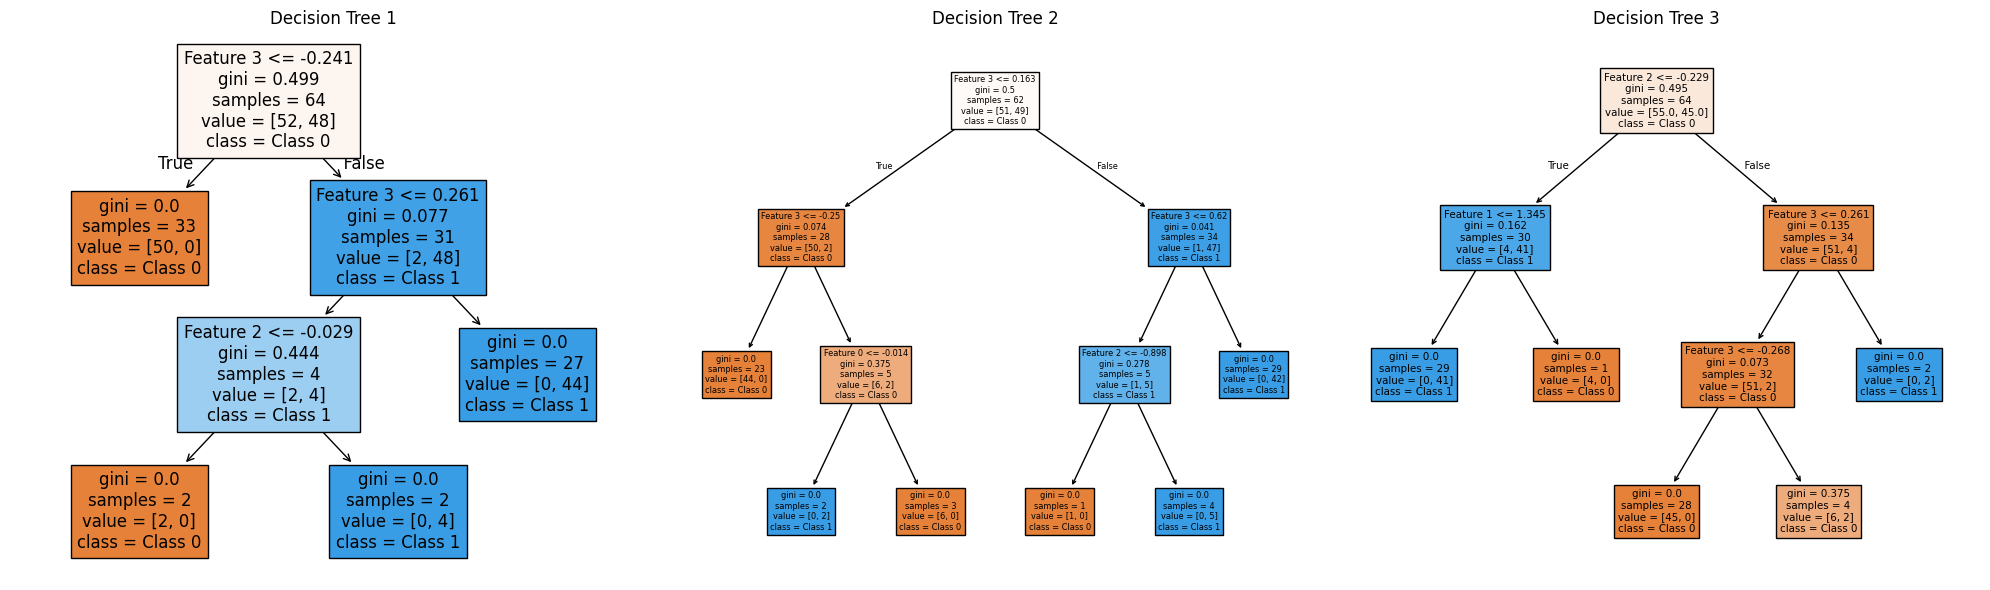

In [2]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.tree import export_graphviz
import graphviz
import numpy as np

# Create sample data
X, y = make_classification(n_samples=100, n_features=4, n_classes=2, random_state=42)

# Train a random forest
rf = RandomForestClassifier(n_estimators=3, max_depth=3, random_state=42)
rf.fit(X, y)

# Visualize individual trees
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, tree_in_rf in enumerate(rf.estimators_):
    # Using scikit-learn's plot_tree (simpler)
    from sklearn.tree import plot_tree
    plot_tree(tree_in_rf, 
              filled=True, 
              feature_names=[f'Feature {i}' for i in range(X.shape[1])],
              class_names=['Class 0', 'Class 1'],
              ax=axes[i])
    axes[i].set_title(f'Decision Tree {i+1}')

plt.tight_layout()
plt.show()

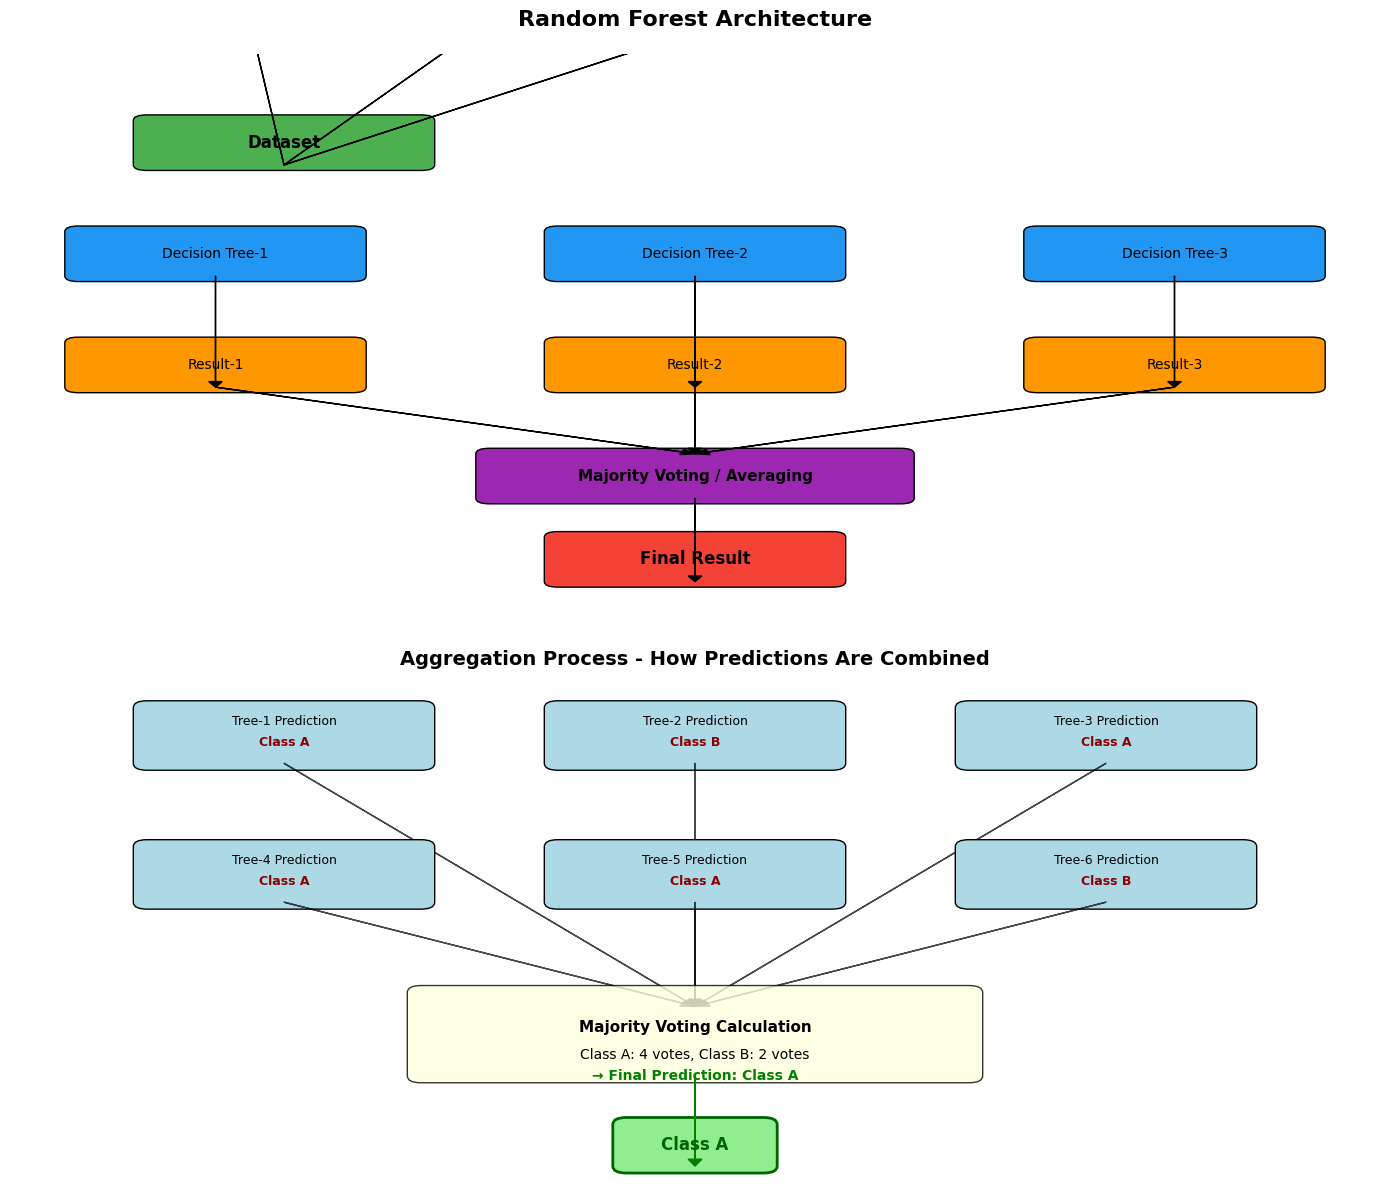

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch
import numpy as np

def create_detailed_random_forest_diagram():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    
    # Diagram 1: Architecture (atas)
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.axis('off')
    
    # Colors
    dataset_color = '#4CAF50'
    tree_color = '#2196F3'
    result_color = '#FF9800'
    final_color = '#F44336'
    
    # Dataset
    dataset_box = FancyBboxPatch((1, 8), 2, 0.8, boxstyle="round,pad=0.1", 
                                facecolor=dataset_color, edgecolor='black')
    ax1.add_patch(dataset_box)
    ax1.text(2, 8.4, 'Dataset', ha='center', va='center', fontsize=12, weight='bold')
    
    # Decision Trees
    tree_positions = [(0.5, 6), (4, 6), (7.5, 6)]
    for i, (x, y) in enumerate(tree_positions):
        tree_box = FancyBboxPatch((x, y), 2, 0.8, boxstyle="round,pad=0.1", 
                                 facecolor=tree_color, edgecolor='black')
        ax1.add_patch(tree_box)
        ax1.text(x+1, y+0.4, f'Decision Tree-{i+1}', ha='center', va='center', fontsize=10)
        
        # Arrows from dataset to trees
        ax1.arrow(2, 8, x+1-2, y-0.8, head_width=0.1, head_length=0.1, 
                 fc='black', ec='black', length_includes_head=True)
    
    # Results
    result_positions = [(0.5, 4), (4, 4), (7.5, 4)]
    for i, (x, y) in enumerate(result_positions):
        result_box = FancyBboxPatch((x, y), 2, 0.8, boxstyle="round,pad=0.1", 
                                   facecolor=result_color, edgecolor='black')
        ax1.add_patch(result_box)
        ax1.text(x+1, y+0.4, f'Result-{i+1}', ha='center', va='center', fontsize=10)
        
        # Arrows from trees to results
        ax1.arrow(tree_positions[i][0]+1, tree_positions[i][1], 
                 0, y-tree_positions[i][1], head_width=0.1, head_length=0.1, 
                 fc='black', ec='black', length_includes_head=True)
    
    # Voting/Averaging
    voting_box = FancyBboxPatch((3.5, 2), 3, 0.8, boxstyle="round,pad=0.1", 
                               facecolor='#9C27B0', edgecolor='black')
    ax1.add_patch(voting_box)
    ax1.text(5, 2.4, 'Majority Voting / Averaging', ha='center', va='center', fontsize=11, weight='bold')
    
    # Final Result
    final_box = FancyBboxPatch((4, 0.5), 2, 0.8, boxstyle="round,pad=0.1", 
                              facecolor=final_color, edgecolor='black')
    ax1.add_patch(final_box)
    ax1.text(5, 0.9, 'Final Result', ha='center', va='center', fontsize=12, weight='bold')
    
    # Arrows from results to voting
    for i, (x, y) in enumerate(result_positions):
        ax1.arrow(x+1, y, 5-(x+1), 2.8-y, head_width=0.1, head_length=0.1, 
                 fc='black', ec='black', length_includes_head=True)
    
    # Arrow from voting to final result
    ax1.arrow(5, 2, 0, 0.5-2, head_width=0.1, head_length=0.1, 
              fc='black', ec='black', length_includes_head=True)
    
    ax1.set_title('Random Forest Architecture', fontsize=16, weight='bold', pad=20)
    
    # Diagram 2: Aggregation Process (bawah)
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 8)
    ax2.axis('off')
    
    # Title for aggregation
    ax2.text(5, 7.5, 'Aggregation Process - How Predictions Are Combined', 
             ha='center', va='center', fontsize=14, weight='bold')
    
    # Individual predictions
    predictions = [
        ('Tree-1 Prediction', 'Class A', 1, 6),
        ('Tree-2 Prediction', 'Class B', 4, 6), 
        ('Tree-3 Prediction', 'Class A', 7, 6),
        ('Tree-4 Prediction', 'Class A', 1, 4),
        ('Tree-5 Prediction', 'Class A', 4, 4),
        ('Tree-6 Prediction', 'Class B', 7, 4)
    ]
    
    for i, (tree_name, pred, x, y) in enumerate(predictions):
        # Prediction box
        pred_box = FancyBboxPatch((x, y), 2, 0.8, boxstyle="round,pad=0.1", 
                                 facecolor='lightblue', edgecolor='black')
        ax2.add_patch(pred_box)
        ax2.text(x+1, y+0.6, tree_name, ha='center', va='center', fontsize=9)
        ax2.text(x+1, y+0.3, pred, ha='center', va='center', fontsize=9, weight='bold', color='darkred')
        
        # Arrow to voting
        ax2.arrow(x+1, y, 5-(x+1), 2.5-y, head_width=0.1, head_length=0.1, 
                 fc='black', ec='black', length_includes_head=True, alpha=0.7)
    
    # Voting process visualization
    voting_process_box = FancyBboxPatch((3, 1.5), 4, 1.2, boxstyle="round,pad=0.1", 
                                       facecolor='lightyellow', edgecolor='black', alpha=0.8)
    ax2.add_patch(voting_process_box)
    
    # Voting calculation
    ax2.text(5, 2.2, 'Majority Voting Calculation', ha='center', va='center', fontsize=11, weight='bold')
    ax2.text(5, 1.8, 'Class A: 4 votes, Class B: 2 votes', ha='center', va='center', fontsize=10)
    ax2.text(5, 1.5, '→ Final Prediction: Class A', ha='center', va='center', fontsize=10, weight='bold', color='green')
    
    # Final result
    final_result_box = FancyBboxPatch((4.5, 0.2), 1, 0.6, boxstyle="round,pad=0.1", 
                                    facecolor='lightgreen', edgecolor='darkgreen', linewidth=2)
    ax2.add_patch(final_result_box)
    ax2.text(5, 0.5, 'Class A', ha='center', va='center', fontsize=12, weight='bold', color='darkgreen')
    
    # Arrow from voting to final
    ax2.arrow(5, 1.5, 0, 0.2-1.5, head_width=0.1, head_length=0.1, 
              fc='green', ec='green', length_includes_head=True)
    
    plt.tight_layout()
    return fig, (ax1, ax2)

# Create the detailed diagram
fig, (ax1, ax2) = create_detailed_random_forest_diagram()
plt.show()

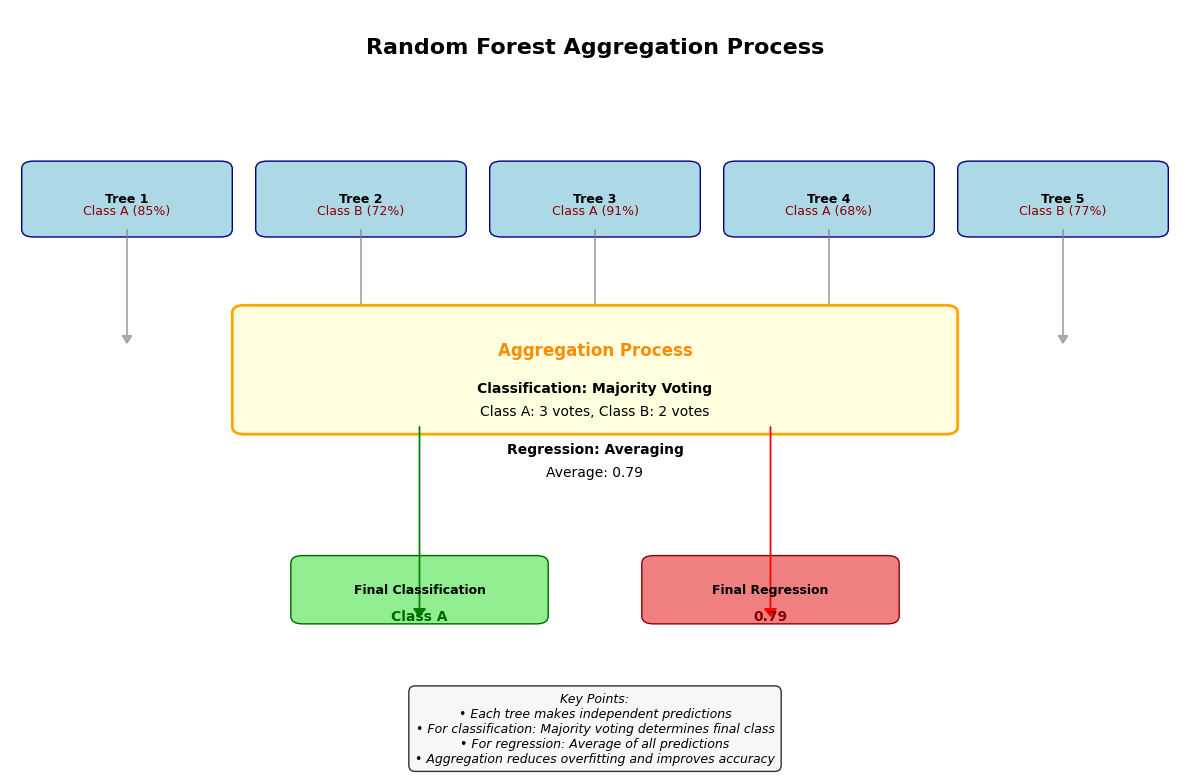

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

def create_aggregation_visualization():
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Title
    ax.text(5, 9.5, 'Random Forest Aggregation Process', 
            ha='center', va='center', fontsize=16, weight='bold')
    
    # Individual tree predictions
    tree_predictions = [
        ('Tree 1', 0.85, 'Class A', 1, 7.5),
        ('Tree 2', 0.72, 'Class B', 3, 7.5),
        ('Tree 3', 0.91, 'Class A', 5, 7.5),
        ('Tree 4', 0.68, 'Class A', 7, 7.5),
        ('Tree 5', 0.77, 'Class B', 9, 7.5)
    ]
    
    # Draw individual predictions
    for tree_name, confidence, prediction, x, y in tree_predictions:
        # Tree prediction box
        pred_box = FancyBboxPatch((x-0.8, y-0.4), 1.6, 0.8, boxstyle="round,pad=0.1",
                                 facecolor='lightblue', edgecolor='navy')
        ax.add_patch(pred_box)
        
        ax.text(x, y, tree_name, ha='center', va='center', fontsize=9, weight='bold')
        ax.text(x, y-0.15, f'{prediction} ({confidence:.0%})', 
                ha='center', va='center', fontsize=9, color='darkred')
        
        # Arrow to aggregation
        ax.arrow(x, y-0.4, 0, -1.5, head_width=0.08, head_length=0.1,
                fc='gray', ec='gray', length_includes_head=True, alpha=0.6)
    
    # Aggregation area
    agg_box = FancyBboxPatch((2, 4.5), 6, 1.5, boxstyle="round,pad=0.1",
                            facecolor='lightyellow', edgecolor='orange', linewidth=2)
    ax.add_patch(agg_box)
    
    # Aggregation details
    ax.text(5, 5.5, 'Aggregation Process', ha='center', va='center', 
            fontsize=12, weight='bold', color='darkorange')
    
    # Classification (Majority Voting)
    ax.text(5, 5.0, 'Classification: Majority Voting', ha='center', va='center', 
            fontsize=10, weight='bold')
    ax.text(5, 4.7, 'Class A: 3 votes, Class B: 2 votes', ha='center', va='center', 
            fontsize=10)
    
    # Regression (Averaging)
    ax.text(5, 4.2, 'Regression: Averaging', ha='center', va='center', 
            fontsize=10, weight='bold')
    ax.text(5, 3.9, f'Average: {(0.85 + 0.72 + 0.91 + 0.68 + 0.77)/5:.2f}', 
            ha='center', va='center', fontsize=10)
    
    # Final results
    final_class_box = FancyBboxPatch((2.5, 2.0), 2, 0.7, boxstyle="round,pad=0.1",
                                   facecolor='lightgreen', edgecolor='darkgreen')
    ax.add_patch(final_class_box)
    ax.text(3.5, 2.35, 'Final Classification', ha='center', va='center', 
            fontsize=9, weight='bold')
    ax.text(3.5, 2.0, 'Class A', ha='center', va='center', 
            fontsize=10, weight='bold', color='darkgreen')
    
    final_reg_box = FancyBboxPatch((5.5, 2.0), 2, 0.7, boxstyle="round,pad=0.1",
                                 facecolor='lightcoral', edgecolor='darkred')
    ax.add_patch(final_reg_box)
    ax.text(6.5, 2.35, 'Final Regression', ha='center', va='center', 
            fontsize=9, weight='bold')
    ax.text(6.5, 2.0, '0.79', ha='center', va='center', 
            fontsize=10, weight='bold', color='darkred')
    
    # Arrows from aggregation to final results
    ax.arrow(3.5, 4.5, 0, 2.0-4.5, head_width=0.1, head_length=0.1,
            fc='green', ec='green', length_includes_head=True)
    ax.arrow(6.5, 4.5, 0, 2.0-4.5, head_width=0.1, head_length=0.1,
            fc='red', ec='red', length_includes_head=True)
    
    # Explanation
    explanation_text = (
        "Key Points:\n"
        "• Each tree makes independent predictions\n"
        "• For classification: Majority voting determines final class\n"
        "• For regression: Average of all predictions\n"
        "• Aggregation reduces overfitting and improves accuracy"
    )
    
    ax.text(5, 1.0, explanation_text, ha='center', va='top', 
            fontsize=9, style='italic', bbox=dict(boxstyle="round,pad=0.5", 
            facecolor='whitesmoke', alpha=0.8))
    
    plt.tight_layout()
    return fig, ax

# Create aggregation visualization
fig, ax = create_aggregation_visualization()
plt.show()